# Numerical simulation for `Double-bracket quantum algorithms for quantum imaginary-time evolution`

### View paper at

https://arxiv.org/abs/2412.04554

### Contact https://mathstodon.xyz/@Marekgluza/113621100092525571

## Contents

1. [Initialization](#Initialization)<br>
     1.1 [Define the input Hamiltonian](#1.1-Define-the-input-Hamiltonian)    
     1.2 [Choose initial state](#1.2-Choose-initial-state)<br>
     1.3 [Implement GCI](#1.3-Implement-GCI)<br>
2. [Run ITE](#2.-Run-ITE)<br>
3. [Run QITE](#3.-Run-QITE)<br>
    
    3.2 [Run QITE DBI](#3.2-Run-QITE-DBI)<br>
    3.3. [Run QITE RGCI with perfect reflections](#3.3-Run-QITE-DBQA-RGCI-with-perfect-reflections)<br>
    3.4. [Run QITE RGCI with approxmate reflections](#3.4-Run-QITE-DBQA-RGCI-with-approximate-reflections)<br>
    3.5 [Run QITE DBQA RHOPF with perfect reflections](#3.5-Run-QITE-DBQA-RHOPF-with-perfect-reflections)<br>
        3.5.1 [Theoretical background of higher-order group-commutators](#3.5.1-Theoretical-background-of-higher-order-group-commutators)<br>
    3.6 [Run QITE DBQA RHOPF with approximate reflections](#3.6-Run-QITE-DBQA-RHOPF-with-approximate-reflections)
4. [Circuit depth analysis](#4.-Circuit-depth-analysis)<br>
4.1 [Counting CZ gates in Qibo](#4.1-Counting-CZ-gates-in-Qibo)<br>
4.2 [Visualization of CZ gate cost](#4.2-Visualization-of-CZ-gate-cost)

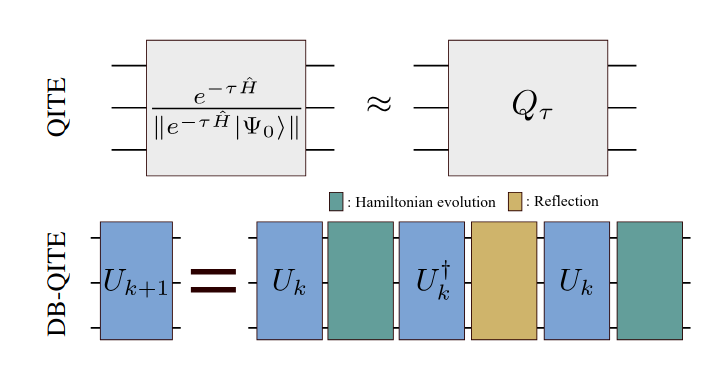

# 1. Initialization

In [8]:
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt


from hyperopt import hp, tpe
from scipy.linalg import expm
set_backend("numpy")

import numpy as np 
import matplotlib.pyplot as plt
from scipy.linalg import expm
import time 

[Qibo 0.2.21|INFO|2025-11-27 11:53:40]: Using numpy backend on /CPU:0


## 1.1 Define the input Hamiltonian

[top](#Contents) 


In [9]:
L_actual = 4
L = 2*L_actual

from local_matrix_class import *
X = X_class(L)
Y = Y_class(L)
Z = Z_class(L)
S_plus = S_plus_class(L)
S_minus = S_minus_class(L)
tick = time.perf_counter()

Id = np.eye( 2**L )
H_hopping = 0*Id #Trivial initialization of the right size matrix
H_interaction = 0*Id

for x in range(1,L-1):
    H_hopping = H_hopping + S_plus.at(x).dot(Z.at(x+1).dot(S_minus.at(x+2))) + S_minus.at(x).dot(Z.at(x+1).dot(S_plus.at(x+2)))

for x in range(1,L_actual+1):
    H_interaction = H_interaction + (Z.at((2*x))-Id).dot(Z.at((2*x-1))-Id)/4

tock = time.perf_counter()
print ('Time needed to create the Hamiltonian on '+str(L)+' sites is '+str(tock-tick) + ' seconds')

Time needed to create the Hamiltonian on 8 sites is 0.06846236100000169 seconds


In [38]:
H = H_hopping + 3* H_interaction
eigenvalues_g, eigenvectors_g = np.linalg.eigh(H)
eigenvalues_g.sort()

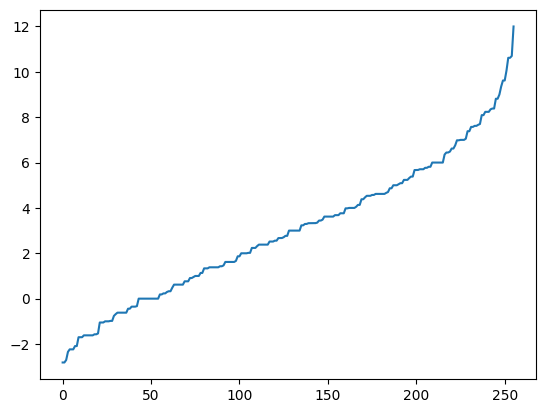

In [39]:
plt.plot(eigenvalues_g)

## 1.2 Choose initial state
[top](#Contents)
We will denote it by $|\psi_0\rangle$

In [53]:
expectation_value = lambda H, psi: (np.conjugate(psi).T @ (H @ psi)).item().real
psi0 = np.zeros([1,2**L]).T
psi0[111] = 1
expectation_value(H,psi0)
expectations_g = [ expectation_value(H, eigenvectors_g[:, i]) for i in range(2**L) ]
target_energy = min(eigenvalues_g)

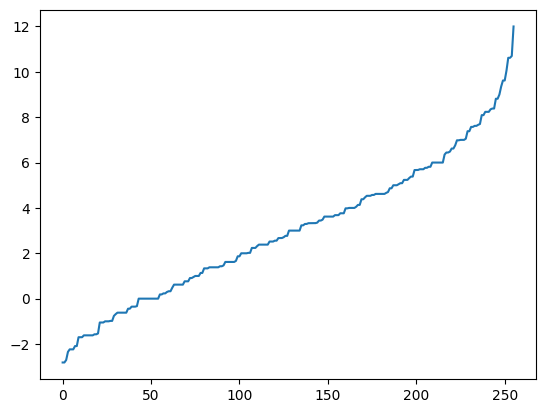

In [41]:
plt.plot(expectations_g)

In [43]:
def select_initial_state( init_type = None ):
    if init_type == "minimize over products":
        es_ini = []
        for i in range(2**L):
            psi0 = np.zeros([1,2**L]).T
            psi0[i] = 1
            es_ini.append(expectation_value(H, psi0))
        min(es_ini)
        psi0 = np.zeros([1,2**L]).T
        psi0[np.argmin(es_ini)] = 1
        PSI0 = psi0 @ psi0.conj().T
        return psi0 , PSI0
    if init_type == "all ones" or init_type is None:
        psi0 = np.zeros([1,2**L]).T
        psi0[-1] = 1
        PSI0 = psi0 @ psi0.conj().T
        return psi0 , PSI0
    if init_type == "all zeros" or init_type is None:
        psi0 = np.zeros([1,2**L]).T
        psi0[0] = 1
        PSI0 = psi0 @ psi0.conj().T
        return psi0 , PSI0
psi0, PSI = select_initial_state("minimize over products") 

In [44]:
H2 = H@H
def compute_moments( psi):
    if isinstance(psi, qibo.Circuit):
        return H_sh.expectation(psi(psi0.T[0]).state()), None, None
    E =  expectation_value(H, psi ) 
    M2 = expectation_value(H2, psi )
    return E, M2, M2 - E**2

In [81]:
psi0, PSI = select_initial_state("all zeros") 
psi0[0] = 0
psi0[112] = 1
compute_moments(psi0)

(3.0, 12.0, 3.0)

## 1.3 Implement GCI
Here we take an approach of  passing the iterating variables and the appropriate step function handle.

[top](#Contents)

In [82]:
def GCI( gci_step, state_of_recursion, nmb_steps, times_dbr, please_be_verbose = True):
    """
    gci_step: takes in state and time and returns state out; the state can be either a pure state or `qibo.Circuit` (to extend to other types overload `compute_moments`)
    """
    results = []
    
    s_mins = [0]
    results.append(compute_moments(state_of_recursion))
    
    if isinstance(state_of_recursion, qibo.Circuit):
        circuit_depths = [0]
        circuits = [state_of_recursion]

    if nmb_steps is None:
        #run GCI for times prescribed in times_dbr
        for s in times_dbr:
            state_of_recursion = gci_step(state_of_recursion, s)
            results.append(compute_moments(state_of_recursion))
        s_mins = [0] + times_dbr
    else:
        #run GCI for nmb_steps with the best generator on the times_dbr grid
        for k in range(nmb_steps):

            test_es = [ compute_moments(gci_step(state_of_recursion,dt))[0] for dt in times_dbr ]
            
            ind = np.argmin(test_es)
            if ind == 0 or ind == len(times_dbr):
                print( k, ind, times_dbr[ind], "--- Warning edge of interval reached")
                
            s_min = times_dbr[ind]
            state_of_recursion = gci_step(state_of_recursion, s_min)

            results.append(compute_moments(state_of_recursion))
            s_mins.append(s_min)
            if isinstance(state_of_recursion, qibo.Circuit):
                circuit_depths.append(len(state_of_recursion.queue)*3)
                circuits.append(state_of_recursion)
                
    energies = [ r[0] for r in results ]
    variances = [ r[1] for r in results ]
    if not hasattr(gci_step, 'exponent'):
        gci_step.exponent = 2
    if not hasattr(gci_step, 'label'):
        gci_step.label = ''
    if not hasattr(gci_step, 'marker'):
        gci_step.marker = '-'
    return (
            energies, s_mins, variances, 
            [ sum(s**gci_step.exponent for s in s_mins[1:x])  for x in range(1,len(s_mins)+1)]if gci_step.exponent > 0 else s_mins,
            gci_step.label, gci_step.marker, 
        circuit_depths if isinstance(state_of_recursion, qibo.Circuit) else None, 
        circuits if isinstance(state_of_recursion, qibo.Circuit) else None
    )
            

def plot_GCI_results(*results, save_path = None):
    import matplotlib.pyplot as plt

    plt.rcParams['axes.labelsize'] = 14
    plt.rcParams['axes.titlesize'] = 14
    plt.rcParams['font.size'] = 12
    plt.rcParams['savefig.dpi'] = 75
    plt.rcParams['lines.linewidth'] = 2.0
    plt.rcParams['lines.markersize'] = 8
    plt.rcParams['legend.fontsize'] = 12
    plt.rcParams['legend.labelspacing'] = .3
    plt.rcParams['legend.columnspacing']= .3
    plt.rcParams['legend.handletextpad']= .1
    plt.rcParams['text.usetex'] = True
    plt.rcParams['font.family'] = "serif"
    plt.rcParams['font.serif'] = "cm"
    plt.rcParams["figure.figsize"] = [5, 3.50]
    plt.rcParams["figure.autolayout"] = True

    for result in results:
        if result[5] == '-':
            plt.plot(result[3], result[0], label=result[4], linestyle = result[5])        
        else:
            plt.plot(result[3], result[0], label=result[4], marker = result[5])


    plt.ylabel('Energy')
    plt.xlabel('Evolution duration')
    y_labels_rounded = [ round(y, 1 ) for y in [results[0][0][0],
                                                results[0][0][-1] ,
                                                (results[0][0][-1]+results[0][0][0])/2,
                                                ((results[0][0][-1]+results[0][0][0])/2+results[0][0][-1])/2,
                                                ((results[0][0][-1]+results[0][0][0])/2+results[0][0][0])/2
                       ] ]
    plt.grid()
    plt.yticks(y_labels_rounded)
    plt.legend(bbox_to_anchor=(1,1))
    plt.axline(  (0, target_energy), ( results[0][3][-1],target_energy), linestyle = ":" )
    
    if save_path is not None:
        plt.savefig(save_path)
    plt.show()

# 2. Run ITE
[top](#Contents)

Imaginary-time evolution is defined by normalizing the action of a non-unitary propagator

$$|\Psi(\tau) \rangle = \frac{e^{-\tau \hat H} |\Psi_0\rangle}  {\| {e^{-\tau \hat H}}|\Psi_0\rangle \| }$$

In [83]:
def ITE_step(psi0, tau):    
    ITE_step.exponent = -1 #in order to use GCI, DBI is an exception in the scaling of the exponent of the DBR duration
    ITE_step.label=r"$ |{\Psi(\tau)}\rangle$"
    ITE_step.marker = '-'

    psi_tau = expm(- tau*H).dot(psi0)
    psi_tau = psi_tau / np.linalg.norm(psi_tau)
    return psi_tau


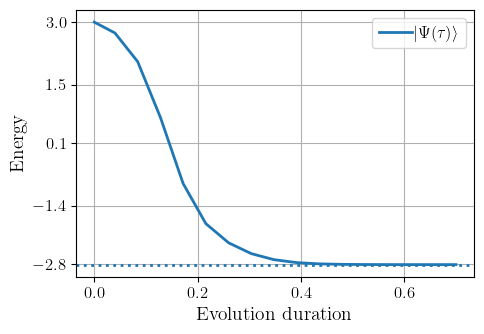

In [84]:

times_ITE = np.linspace(0.04,.7,16).tolist()
results_ITE = GCI(ITE_step,psi0, None, times_ITE)
plot_GCI_results(results_ITE)

In [85]:
energies_ITE = results_ITE[0]
energies_ITE[-1]

-2.814251182608352

In [86]:
target_energy

np.float64(-2.814282749541713)

# 3. Run QITE 

## 3.2 Run QITE DBI

Using casting of the Hamiltonian to its dense form we define the `QITE_DBI_step` by using `scipy.linalg.expm` as for [ITE](#1.-Run-ITE)

[top](#Contents)

In [87]:
def QITE_DBI_step(psi, s):
    QITE_DBI_step.exponent = 1 #in order to use GCI, DBI is an exception in the scaling of the exponent of the DBR duration
    QITE_DBI_step.label=r"$ |{\sigma_k}\rangle$"
    QITE_DBI_step.marker = 'o'
    
    PSI = psi@psi.T.conj()
    return expm(s *(PSI@H - H @PSI) )@ psi

results_DBI = GCI( QITE_DBI_step, psi0, 7, np.linspace(.01,.3,10) )   
    

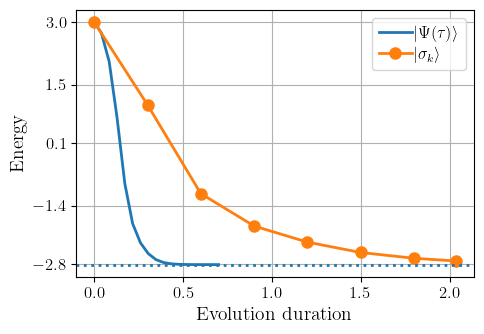

In [88]:
plot_GCI_results(results_ITE,results_DBI)

In [89]:
results_DBI[0][-1]

-2.7273103922165114

In [90]:
target_energy

np.float64(-2.814282749541713)

## 3.3 Run DB-QITE with perfect reflections

$$ |{\omega_{k+1}} \rangle= e^{i\sqrt{s_k}H} e^{i\sqrt{s_k}\omega_k}   
    e^{-i\sqrt{s_k}H}|{\omega_k}\rangle$$

where $\omega_k = |\omega_k\rangle\langle \omega_k|$

[top](#Contents)

In [91]:
def QITE_RGCI_step(psi, s):
    QITE_RGCI_step.label=r"$ |{\omega_k}\rangle$"
    QITE_RGCI_step.marker = 'x'
    
    PSI = psi@psi.T.conj()
    U_t = expm(1j*s *H )
    return U_t @ expm(1j *s * PSI) @ U_t.conj().T @ psi


results_RGCI = GCI( QITE_RGCI_step, psi0, 10, np.linspace(.1,.3,10) )   

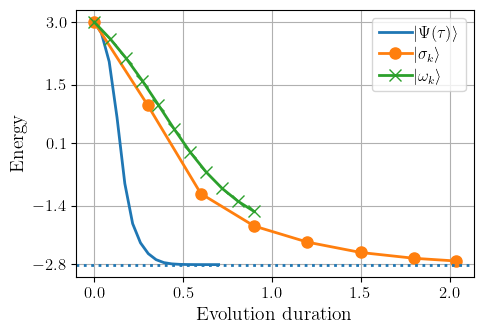

In [92]:
plot_GCI_results(results_ITE,results_DBI,results_RGCI)

## 3.4 Run DB-DOI with the Hubbard interaction


[top](#Contents)

In [93]:
def QITE_RGCI_ZZ_step(psi,s):
    QITE_RGCI_ZZ_step.label=r"$ |{\omega_k}'\rangle$"
    QITE_RGCI_ZZ_step.marker = '.'
    
    PSI = psi@psi.T.conj()
    U_t = expm(1j*s *H )
    U_diag = expm(-1j*s* H_interaction)
    return U_t @ U_diag @ U_t.conj().T @ psi

        
results_RGCI_ZZ = GCI( QITE_RGCI_ZZ_step, psi0, 3, np.linspace(.01,1,40) )   

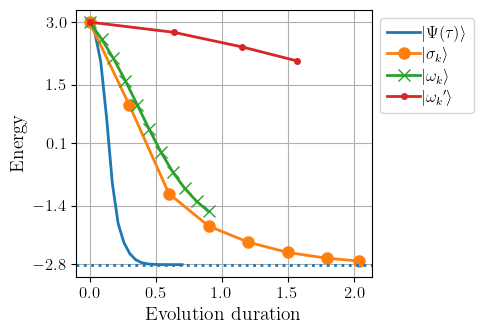

In [94]:
plot_GCI_results(results_ITE,results_DBI,results_RGCI,results_RGCI_ZZ)        

In [112]:
H_interaction2 = 0*Id
for x in range(1,L):
    H_interaction2 = H_interaction2 + np.cos(6*x) *Z.at(x)    

In [136]:
    
def QITE_RGCI_ZZ_step2(psi,s):
    QITE_RGCI_ZZ_step2.label=r"$ |{\omega_k}'\rangle$"
    QITE_RGCI_ZZ_step2.marker = 's'
    
    PSI = psi@psi.T.conj()
    U_t = expm(1j*s *H )
    U_diag = expm(-1j*s* H_interaction)
    return U_diag.conj().T @U_t @U_diag@ psi


results_RGCI_ZZ2 = GCI( QITE_RGCI_ZZ_step2, psi0, 3, np.linspace(3,6,10) )   

0 0 3.0 --- Warning edge of interval reached


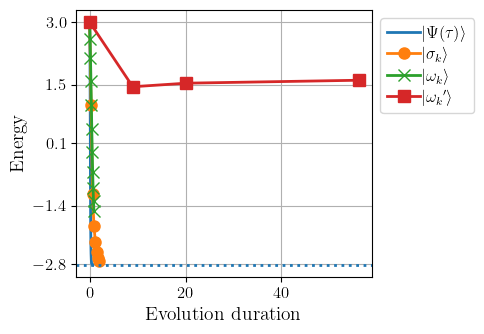

In [137]:
plot_GCI_results(results_ITE,results_DBI,results_RGCI,results_RGCI_ZZ2)        

## 3.5 Run QITE DBQA RHOPF with perfect reflections

### 3.5.1 Theoretical background of higher-order group-commutators


The following formula is given in Eq. (8) of [Chen et al PRR 2022](https://journals.aps.org/prresearch/abstract/10.1103/PhysRevResearch.4.013191)
\begin{align}
	V^{\text{(HOPF)}}(A,B) = 
	e^{ i \phi A}
	e^{i \phi B}
	e^{-i A}
	e^{-i(\phi+1) B}
	e^{i (1-\phi) A}
	e^{iB}\ 
\end{align}
with $\phi = \frac  12 (\sqrt 5 -1)$.

This is designed to approximate a double-bracket rotation 
$$V^{\text{(HOPF)}}(A,B)\approx e^{-[A,B]} $$
To use it for a group commutator iteration we can set
\begin{align}
	V_k = V^{\text{(HOPF)}}(\sqrt{s_k}H,\sqrt{s_k}\omega_k)  = e^{s_k[\omega_k,H]} + O(s_k^2)\ 
\end{align}

W will be applying $V_k|\omega_k\rangle$ so we drop the phase coming from the last unitary
\begin{align}
	V^{\text{(RHOPF)}}(A,B) = 
	e^{ i \phi A}
	e^{i \phi B}
	e^{-i A}
	e^{-i(\phi+1) B}
	e^{i (1-\phi) A}\ .
\end{align}
And use 
\begin{align}
	V_k = V^{\text{(RHOPF)}}(\sqrt{s_k}H,\sqrt{s_k}\omega_k)  = e^{s_k[\omega_k,H]}  + O(s_k^2)\ .
\end{align}
to define the QITE RHOPF GCI DBQA state while benefiting from 1 less query to reflections around the input state.

To clarify, we broadly speak of QITE DBQA anytime we find a synthesis in terms of products of unitaries such that the QITE DBI is approximated in every step.
Here we refer to RGCI as the reduced form of the group commutator and RHOPF is the reduced higher-order product formula.


[top](#Contents)

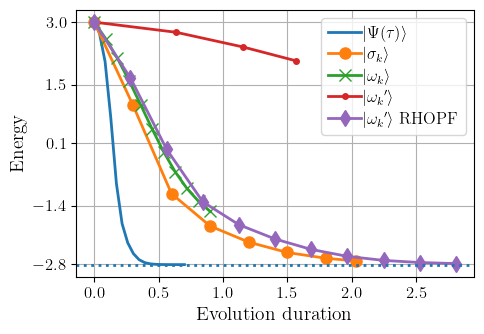

In [120]:
def QITE_RHOPF_step(psi, s): 
    phi = 0.5*(np.sqrt(5)-1)
    QITE_RHOPF_step.label=r"$ |{\omega_k}'\rangle$ RHOPF"
    QITE_RHOPF_step.marker = 'd'
   # Default: exact diagonalization
    U_t = expm(1j* s *H )
    U_t_phi = expm(1j* s *phi*H )
    PSI = psi@psi.T.conj()
    PSI_t = expm(1j * s * PSI)
    PSI_t_phi = expm(1j * s * phi * PSI)
    return U_t_phi @ PSI_t_phi @ U_t.conj().T @ PSI_t_phi.conj().T @PSI_t.conj().T @ U_t @ U_t_phi.conj().T @ psi





results_RHOPF_ED = GCI( QITE_RHOPF_step, psi0, 10, np.linspace(.1,.53,10)  )
    
plot_GCI_results(results_ITE,results_DBI,results_RGCI,results_RGCI_ZZ,results_RHOPF_ED)

## 3.5 Run DB-DOI simple and RHOPF 

### 3.5.1 Theoretical background of higher-order group-commutators


The following formula is given in Eq. (8) of [Chen et al PRR 2022](https://journals.aps.org/prresearch/abstract/10.1103/PhysRevResearch.4.013191)
\begin{align}
	V^{\text{(HOPF)}}(A,B) = 
	e^{ i \phi A}
	e^{i \phi B}
	e^{-i A}
	e^{-i(\phi+1) B}
	e^{i (1-\phi) A}
	e^{iB}\ 
\end{align}
with $\phi = \frac  12 (\sqrt 5 -1)$.

This is designed to approximate a double-bracket rotation 
$$V^{\text{(HOPF)}}(A,B)\approx e^{-[A,B]} $$
To use it for a group commutator iteration we can set
\begin{align}
	V_k = V^{\text{(HOPF)}}(\sqrt{s_k}H,\sqrt{s_k}\omega_k)  = e^{s_k[\omega_k,H]} + O(s_k^2)\ 
\end{align}

W will be applying $V_k|\omega_k\rangle$ so we drop the phase coming from the last unitary
\begin{align}
	V^{\text{(RHOPF)}}(A,B) = 
	e^{ i \phi A}
	e^{i \phi B}
	e^{-i A}
	e^{-i(\phi+1) B}
	e^{i (1-\phi) A}\ .
\end{align}
And use 
\begin{align}
	V_k = V^{\text{(RHOPF)}}(\sqrt{s_k}H,\sqrt{s_k}\omega_k)  = e^{s_k[\omega_k,H]}  + O(s_k^2)\ .
\end{align}
to define the QITE RHOPF GCI DBQA state while benefiting from 1 less query to reflections around the input state.

To clarify, we broadly speak of QITE DBQA anytime we find a synthesis in terms of products of unitaries such that the QITE DBI is approximated in every step.
Here we refer to RGCI as the reduced form of the group commutator and RHOPF is the reduced higher-order product formula.


[top](#Contents)

In [162]:
phi = 0.5*(np.sqrt(5)-1)
results = []

results.append(compute_moments(psi0)[0])
for s in np.linspace(0.01,9,100):
 

    # Default: exact diagonalization
    A = expm(1j* s *H )
    A_phi = expm(1j* s *phi*H )
    B = expm(-1j*s* H_interaction2)
    B_phi = expm(-1j*s* phi* H_interaction2)

    U = A_phi @ B_phi @ A.conj().T @ B_phi.conj().T @ B.conj().T @ A @ A_phi.conj().T @ B


    results.append(compute_moments(U @ psi0)[0])

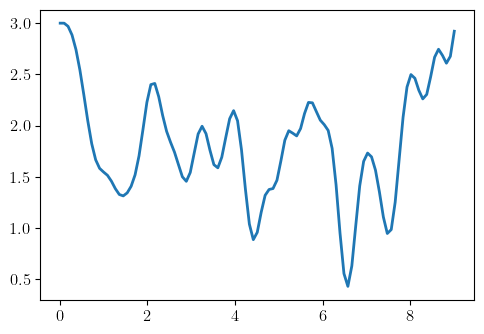

In [163]:
plt.plot(np.linspace(0.01,9,101),results)

In [169]:
np.linspace(0.01,9,101)[np.argmin(results[0:20])]

np.float64(1.4484000000000001)

In [172]:
s = np.linspace(0.01,9,101)[np.argmin(results)]
A = expm(1j* s *H )
A_phi = expm(1j* s *phi*H )
B = expm(-1j*s* H_interaction2)
B_phi = expm(-1j*s* phi* H_interaction2)

U_0 = A_phi @ B_phi @ A.conj().T @ B_phi.conj().T @ B.conj().T @ A @ A_phi.conj().T @ B

phi = 0.5*(np.sqrt(5)-1)
results2 = []

results2.append(compute_moments(U_0@psi0)[0])
for s in np.linspace(0.01,.5,10):
 

    # Default: exact diagonalization
    A = U_0@expm(1j* s *H )@U_0
    A_phi = U_0@expm(1j* s *phi*H )@U_0
    B = expm(-1j*s* H_interaction2)
    B_phi = expm(-1j*s* phi* H_interaction2)

    U = A_phi @ B_phi @ A.conj().T @ B_phi.conj().T @ B.conj().T @ A @ A_phi.conj().T @ B


    results2.append(compute_moments(U_0@U @ psi0)[0])

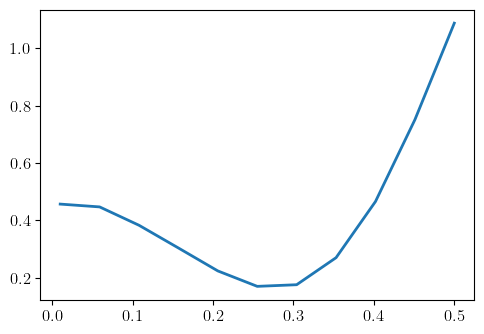

In [173]:
plt.plot(np.linspace(0.01,.5,11),results2)

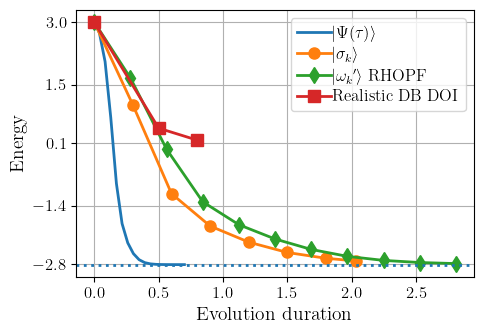

In [178]:
energies = [results[0],results2[0],np.min(results2)]
s_min = [0, s, s+0.3]
plot_GCI_results(results_ITE,results_DBI,results_RHOPF_ED, [energies, s_min, s_min, s_min, "Realistic DB DOI", 's'])

In [ ]:
res